# 네트워크 분석
- **노드(node)와 엣지(edge)** 로 이루어진 관계망을 시각화하고 분석하는 기법
    - 노드 (Node): 분석 대상 (예: 사람, 단어, 웹 페이지 등)
    - 엣지 (Edge): 노드 간의 관계 또는 연결 (예: 친구 관계, 단어 간 동시 등장)
- 목적
    - 복잡한 관계를 시각화하고 네트워크 내에서 중요한 요소를 파악하는 것
    - 소셜 네트워크 분석(SNA), 단어 네트워크 분석, 추천 시스템, 웹 크롤링 분석 등에서 널리 사용

In [1]:
# colab 환경에서 한글 패치
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [1]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 데이터 불러오기
df = pd.read_csv('result.csv')
df.head()


,작성자,평점,날짜,리뷰내용
0,강성원,1,2026-05-30 23:38:18,오늘의 포인트를 하려면 업데이트를.하라고 문구가 뜨는데 업데이트가 되지 않음
1,고태성,4,2026-05-30 23:02:01,좋아요
2,김기형,5,2026-05-30 22:56:35,편리함
3,최경자,5,2026-05-30 22:49:31,재미있어요
4,정현정카슈,3,2026-05-30 22:44:51,잘모르겠음


In [10]:
# 컬럼명의 앞뒤 공백 제거
df.columns = df.columns.str.strip()

# 존재하는 컬럼만 삭제
df.drop(columns=['작성자', '평점', '날짜'], errors='ignore', inplace=True)

df.dropna(inplace=True)
df = df.drop_duplicates(subset=['리뷰내용'])

df.head()

,level_0,index,리뷰내용
0,0,0,오늘의 포인트를 하려면 업데이트를.하라고 문구가 뜨는데 업데이트가 되지 않음
1,1,1,좋아요
2,2,2,편리함
3,3,3,재미있어요
4,4,4,잘모르겠음


In [11]:
import re
from konlpy.tag import Okt
from tqdm import tqdm

In [12]:
noun_result = []

for temp in tqdm(df['리뷰내용']):
    temp_result = re.sub(r'[^ㄱ-ㅣ가-힣\s]', '', temp)

    okt = Okt()

    temp_nouns = okt.nouns(temp_result)

    temp_nouns_result = [x for x in temp_nouns if len(x) > 1]

    noun_result.append(temp_nouns_result)

print(noun_result)

  0%|          | 0/134 [00:00<?, ?it/s]

100%|██████████| 134/134 [00:06<00:00, 21.86it/s] 

[['오늘', '포인트', '업데이트', '하라', '문구', '업데이트'], [], [], [], [], ['수수료', '매일', '자주', '방송', '포인트', '업뎃', '하래', '계속', '업뎃해', '이용', '업뎃', '벌써', '언제', '반영'], ['매우'], ['통장', '잔액', '재부팅', '잔액', '얼마', '확인', '시간'], ['재미'], ['포인트', '주지', '시오'], [], ['공유'], ['사용'], ['아주'], ['실행', '상단', '대출', '광고', '표시', '계속', '길거리', '명함', '사채', '업자'], ['일주일', '방문', '미션', '가끔', '정답', '정답', '인정', '토스', '이용'], ['이번', '미션', '이안'], ['토스', '작동'], [], ['업데이트', '무한', '반복', '열기', '계속', '제자리', '서버', '안정화', '실행'], ['환급', '준비', '서류', '안내', '순서대로', '결제', '마지막', '서류', '요구', '서류', '경정', '청구', '장난', '부동산', '류구', '지도', '염장', '엔화', '장난', '이제', '환급', '장난'], ['보기', '복권', '만원', '만원', '기본', '윈입니', '매일', '뭐합', '사람', '차별', '하나요', '무시'], ['사용'], ['토스', '돈독', '환급금', '수수료', '알림', '설정', '전부', '해제', '배너', '만듭니'], ['공유'], ['미션', '클릭', '업데이트', '하라', '업데이트'], [], ['이번', '미션', '오늘', '포인트', '미션', '언제', '이용', '가요', '업데이트', '이틀', '업데이트', '하라', '플레이스토어', '포인트', '얻지', '건가', '차라리', '이전'], ['수수료', '먼저', '수수료', '안내', '미리', '정차', '요구', '홈택스', '비번', '인증서', '홈

In [7]:
# !pip install apyori

- 장바구니 분석 : 함께 구매되거나 함께 등장하는 항목 조합을 찾아 연관 규칙을 발견하는 분석 방법
- 장바구니 분석에서 Apriori 알고리즘은 자주 함께 등장하는 항목 조합을 찾는다.
- 네트워크 분석은 그 관계를 노드와 연결선으로 시각화하고 구조적으로 해석하는 방법이다.

- Support (지지도)
    - 특정 항목 집합이 데이터에서 얼마나 자주 발생하는지를 나타낸다.
    - 예를 들어, Support({A, B}) = 0.2는 전체 거래 중 20%에서 A와 B가 함께 구매되었음을 의미한다.

- Confidence (신뢰도)
    - A가 주어졌을 때 B가 발생할 확률을 나타낸다.
    - 예를 들어, Confidence(A -> B) = 0.8은 A를 구매한 고객 중 80%가 B도 구매했음을 의미한다.

- Lift (향상도)
    - A와 B가 서로 독립적인 경우에 비해 A가 발생할 때 B가 발생할 가능성의 비율을 나타낸다.
    - 예를 들어, Lift(A -> B) = 1.5는 A가 있는 경우 B가 발생할 가능성이 1.5배 높음을 의미한다.
    - Lift 값이 1보다 크면 양의 상관관계, 1보다 작으면 음의 상관관계를 의미한다.

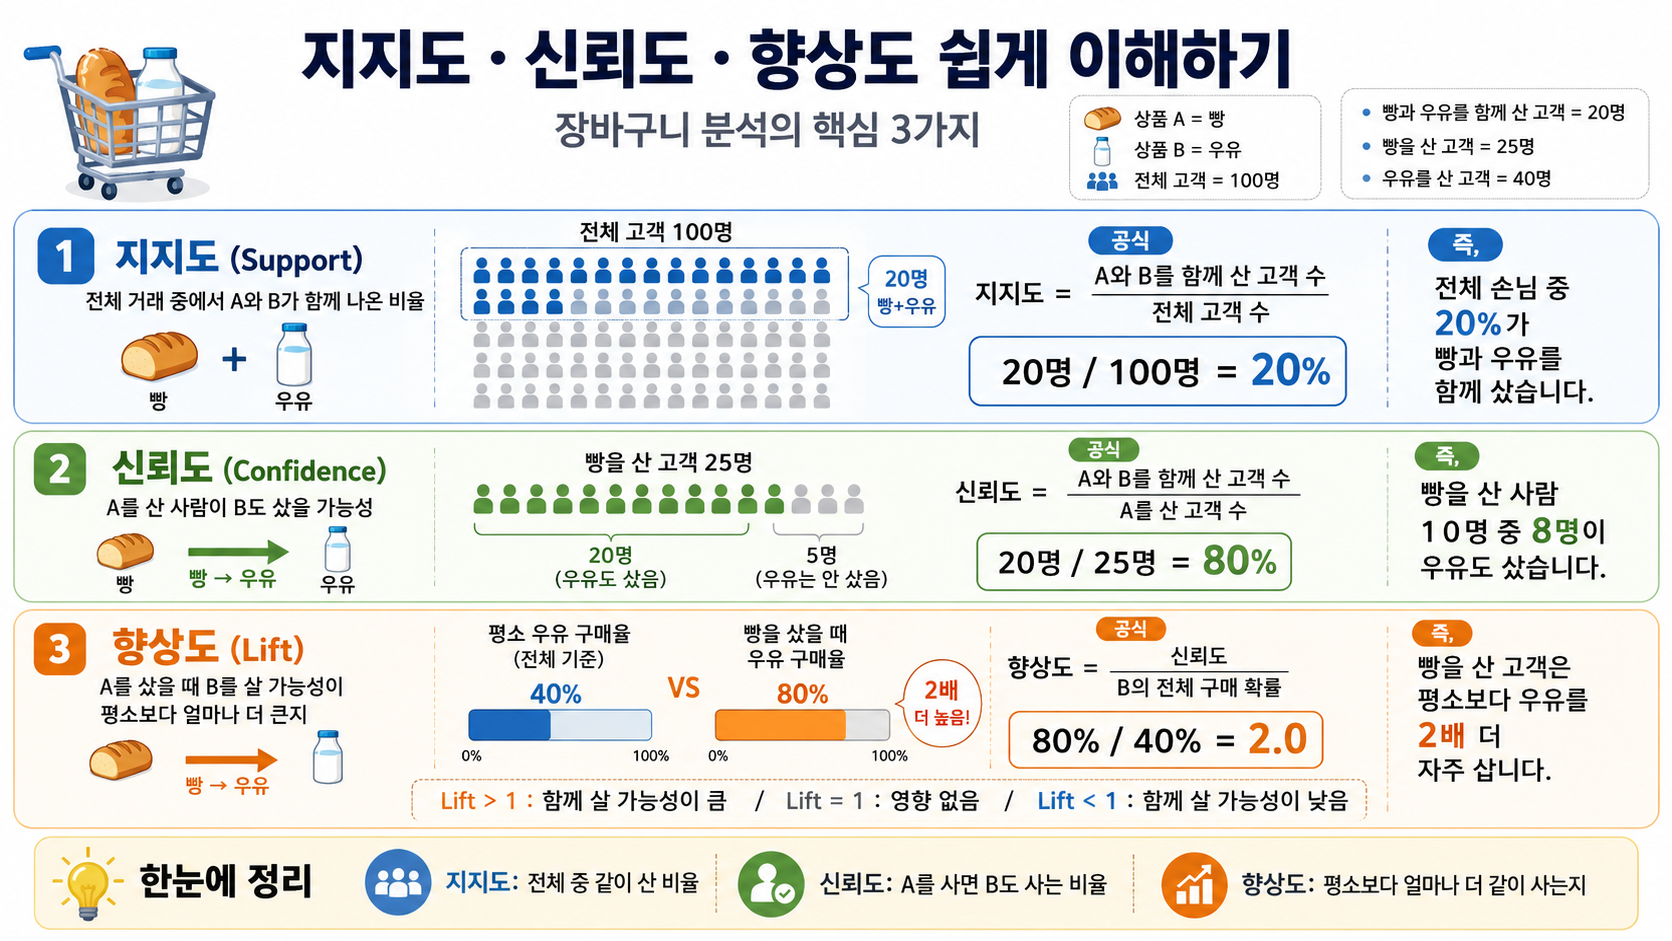

In [13]:
# Apriori
from apyori import apriori

In [14]:
# Apriori 알고리즘 적용
result = list(apriori(noun_result,
                      min_support=0.05))
print(result)

[RelationRecord(items=frozenset({'계속'}), support=0.1044776119402985, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'계속'}), confidence=0.1044776119402985, lift=1.0)]), RelationRecord(items=frozenset({'미션'}), support=0.1791044776119403, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'미션'}), confidence=0.1791044776119403, lift=1.0)]), RelationRecord(items=frozenset({'사용'}), support=0.1044776119402985, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'사용'}), confidence=0.1044776119402985, lift=1.0)]), RelationRecord(items=frozenset({'업데이트'}), support=0.22388059701492538, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'업데이트'}), confidence=0.22388059701492538, lift=1.0)]), RelationRecord(items=frozenset({'오늘'}), support=0.08208955223880597, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'오늘'}), confidence=0.0820895522388

In [15]:
df = pd.DataFrame(result)
df

# ordered_statistcs (기준단어, 같이 나오는 단어, support, lift)

,items,support,ordered_statistics
0,frozenset({계속}),0.104478,"[(frozenset({}), frozenset({계속}), 0.1044776119..."
1,frozenset({미션}),0.179104,"[(frozenset({}), frozenset({미션}), 0.1791044776..."
2,frozenset({사용}),0.104478,"[(frozenset({}), frozenset({사용}), 0.1044776119..."
3,frozenset({업데이트}),0.223881,"[(frozenset({}), frozenset({업데이트}), 0.22388059..."
4,frozenset({오늘}),0.082090,"[(frozenset({}), frozenset({오늘}), 0.0820895522..."
5,frozenset({이번}),0.097015,"[(frozenset({}), frozenset({이번}), 0.0970149253..."
6,frozenset({토스}),0.104478,"[(frozenset({}), frozenset({토스}), 0.1044776119..."
7,frozenset({포인트}),0.104478,"[(frozenset({}), frozenset({포인트}), 0.104477611..."
8,frozenset({하라}),0.082090,"[(frozenset({}), frozenset({하라}), 0.0820895522..."
9,"frozenset({계속, 업데이트})",0.052239,"[(frozenset({}), frozenset({계속, 업데이트}), 0.0522..."


In [16]:
# 각 item 열의 길이를 저장할 리스트
item_len=[]

# apriori 결과의 items는 fronzenset 형태이므로 len()으로 조합에 포함된 단어 수를 계산.
for temp in df['items']:
    item_len.append(len(temp))

# 새로운 열에 각 리스트의 길이 저장
df['length'] = item_len
df.head()

,items,support,ordered_statistics,length
0,frozenset({계속}),0.104478,"[(frozenset({}), frozenset({계속}), 0.1044776119...",1
1,frozenset({미션}),0.179104,"[(frozenset({}), frozenset({미션}), 0.1791044776...",1
2,frozenset({사용}),0.104478,"[(frozenset({}), frozenset({사용}), 0.1044776119...",1
3,frozenset({업데이트}),0.223881,"[(frozenset({}), frozenset({업데이트}), 0.22388059...",1
4,frozenset({오늘}),0.082090,"[(frozenset({}), frozenset({오늘}), 0.0820895522...",1


In [20]:
# Apriori 분석 결과 중에서 네트워크 그래프의 엣지로 사용할 단어 쌍만 고름
# 항목이 2개인 조합만 선택하여 단어와 단어 사이의 연결
# support가 너무 낮은 조합까지 포함하면 그래프가 복잡해지고 해석하기 어려워짐.

df = df[(df['length']==2)&(df['support'] >= 0.02)]
df

,items,support,ordered_statistics,length
10,"frozenset({미션, 업데이트})",0.134328,"[(frozenset({}), frozenset({미션, 업데이트}), 0.1343...",2
11,"frozenset({오늘, 미션})",0.074627,"[(frozenset({}), frozenset({오늘, 미션}), 0.074626...",2
12,"frozenset({이번, 미션})",0.089552,"[(frozenset({}), frozenset({이번, 미션}), 0.089552...",2
14,"frozenset({오늘, 업데이트})",0.067164,"[(frozenset({}), frozenset({오늘, 업데이트}), 0.0671...",2
15,"frozenset({이번, 업데이트})",0.067164,"[(frozenset({}), frozenset({이번, 업데이트}), 0.0671...",2
16,"frozenset({하라, 업데이트})",0.074627,"[(frozenset({}), frozenset({하라, 업데이트}), 0.0746...",2


In [18]:
# networks : 노드와 엣지로 구성된 네트워크 그래프를 만들고 분석하는 라이브러리.
import networkx as nx

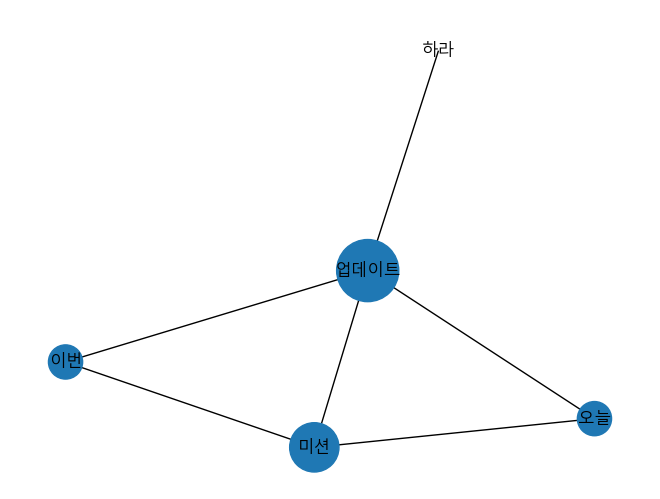

In [21]:
# 단어 관계의 방향이 없는 무방향성 그래프를 사용.
G = nx.Graph()

# Apriori 결과의 items 열에는 네트워크 엣지가 될 단어 쌍이 들어 있음.
ar = df['items']

# 예: {'배달', '주문'} -> 배달 노드와 주문 노드를 연결
G.add_edges_from(ar)

# 상대적으로 중요한 노드 계산
pr = nx.pagerank(G)

nsize = np.array([temp for temp in pr.values()])
nsize = 2000 * (nsize - min(nsize)) / (max(nsize) - min(nsize))

pos = nx.kamada_kawai_layout(G)

plt.rc('font', family='Malgun Gothic')

nx.draw(G,
        node_size=nsize,
        with_labels=True,
        font_family='Malgun Gothic'
         )
plt.show()